# 01 — Monthly Sales & Profit Trend
Track revenue and profit over time to spot seasonal patterns and growth trajectories.

## Setup — Spark Session & Load HDFS Tables

In [1]:
import os, sys

os.environ["JAVA_HOME"]             = "/usr/local/java"
os.environ["SPARK_HOME"]            = "/usr/local/spark"
os.environ["HADOOP_CONF_DIR"]       = "/usr/local/hadoop/etc/hadoop"
os.environ["PYSPARK_PYTHON"]        = sys.executable
os.environ["PYSPARK_DRIVER_PYTHON"] = sys.executable

import findspark
findspark.init()

from pyspark.sql import SparkSession

spark = SparkSession.getActiveSession()
if spark is None:
    spark = (SparkSession.builder
        .appName("01 — Monthly Sales & Profit Trend")
        .master("spark://namenode:7077")
        .config("spark.sql.shuffle.partitions", "4")
        .getOrCreate())

spark.sparkContext.setLogLevel("WARN")

HDFS_BASE = "hdfs:///data"

def load_csv(name, renames):
    df = (spark.read
          .option("header", "true")
          .option("inferSchema", "true")
          .csv(f"{HDFS_BASE}/{name}.csv"))
    for old, new in renames.items():
        df = df.withColumnRenamed(old, new)
    df.createOrReplaceTempView(name)
    return df

load_csv("customers",   {"Customer ID":"customer_id","Customer Name":"customer_name","Segment":"segment"})
load_csv("orders",      {"Order ID":"order_id","Order Date":"order_date","Ship Date":"ship_date",
                          "Ship Mode":"ship_mode","Customer ID":"customer_id","Postal Code":"postal_code"})
load_csv("order_items", {"Row ID":"row_id","Order ID":"order_id","Product ID":"product_id",
                          "Sales":"sales","Quantity":"quantity","Discount":"discount","Profit":"profit"})
load_csv("products",    {"Product ID":"product_id","Product Name":"product_name",
                          "Category":"category","Sub-Category":"sub_category"})
load_csv("locations",   {"Postal Code":"postal_code","City":"city","State":"state",
                          "Country":"country","Region":"region"})

import matplotlib.pyplot as plt
%matplotlib inline
import matplotlib.ticker as mticker
import pandas as pd
import numpy as np

plt.rcParams.update({"figure.dpi": 120, "axes.spines.top": False, "axes.spines.right": False})

CHARTS_DIR = "/usr/local/hadoop/etc/hadoop/assessment-2/charts"
os.makedirs(CHARTS_DIR, exist_ok=True)
print("Ready.")


Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/05/01 09:43:49 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
26/05/01 09:43:50 WARN Utils: Service 'SparkUI' could not bind on port 4040. Attempting port 4041.
                                                                                

Ready.


## Query

In [2]:
df = spark.sql('''
    SELECT
        DATE_FORMAT(TO_DATE(o.order_date, "M/d/yyyy"), "yyyy-MM") AS month,
        ROUND(SUM(oi.sales),  2) AS total_sales,
        ROUND(SUM(oi.profit), 2) AS total_profit
    FROM orders o
    JOIN order_items oi ON o.order_id = oi.order_id
    GROUP BY month
    ORDER BY month
''').toPandas()
print(df.head())

     month  total_sales  total_profit
0  2014-01     14236.89       2450.19
1  2014-02      4519.89        862.31
2  2014-03     55691.01        498.73
3  2014-04     28295.34       3488.84
4  2014-05     23648.29       2738.71


## Visualisation

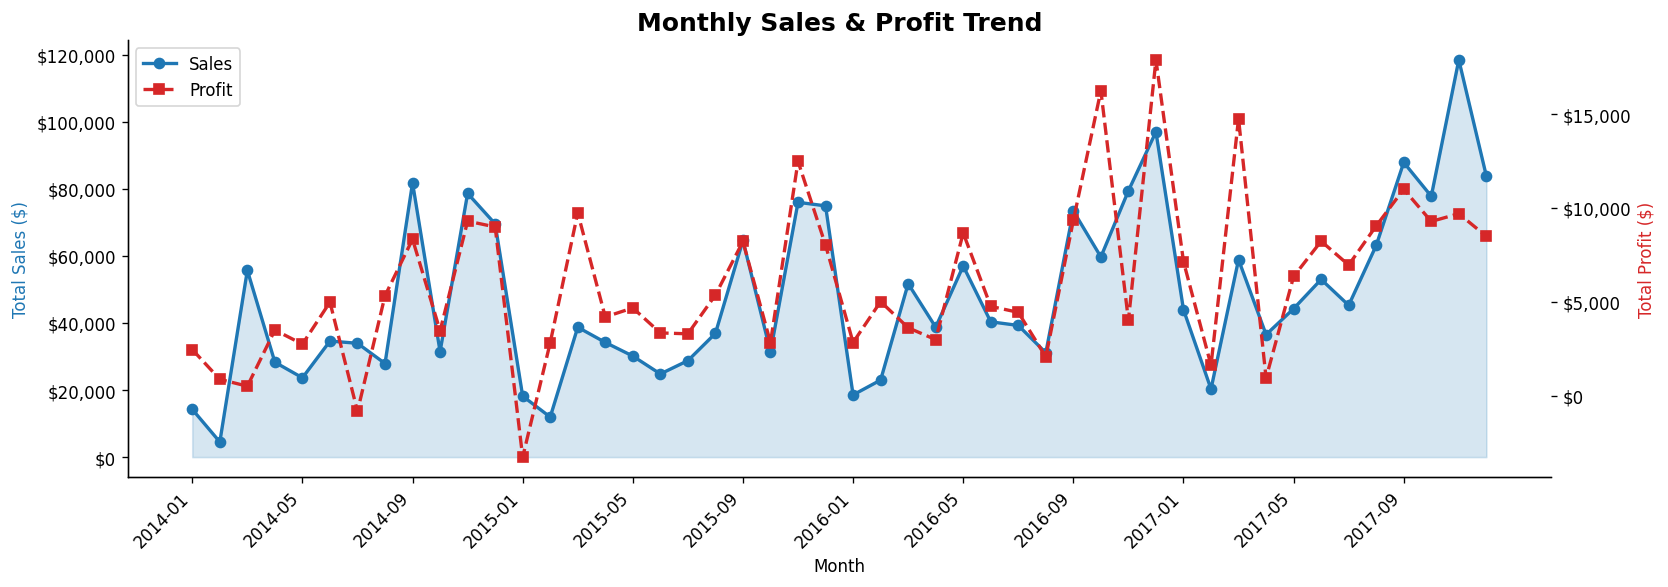

Chart saved to /usr/local/hadoop/etc/hadoop/assessment-2/charts/01_monthly_sales_trend.png


In [3]:
fig, ax1 = plt.subplots(figsize=(14, 5))
ax2 = ax1.twinx()

ax1.fill_between(df["month"], df["total_sales"], alpha=0.18, color="#1f77b4")
ax1.plot(df["month"], df["total_sales"],  marker="o", color="#1f77b4", lw=2, label="Sales")
ax2.plot(df["month"], df["total_profit"], marker="s", color="#d62728", lw=2, ls="--", label="Profit")

step = max(1, len(df) // 12)
ax1.set_xticks(range(0, len(df), step))
ax1.set_xticklabels(df["month"].iloc[::step], rotation=45, ha="right")
ax1.set_xlabel("Month"); ax1.set_ylabel("Total Sales ($)", color="#1f77b4")
ax2.set_ylabel("Total Profit ($)", color="#d62728")
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f"${v:,.0f}"))
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f"${v:,.0f}"))

lines1, lab1 = ax1.get_legend_handles_labels()
lines2, lab2 = ax2.get_legend_handles_labels()
ax1.legend(lines1+lines2, lab1+lab2, loc="upper left")
ax1.set_title("Monthly Sales & Profit Trend", fontsize=15, fontweight="bold")
plt.tight_layout(); plt.savefig(f"{CHARTS_DIR}/01_monthly_sales_trend.png", bbox_inches="tight")
plt.show()
print(f"Chart saved to {CHARTS_DIR}/01_monthly_sales_trend.png")

## Stop Spark

In [4]:
spark.stop()
print("Spark session stopped.")

Spark session stopped.
